In [2]:
import os
import numpy as np
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


ModuleNotFoundError: No module named 'core'

In [4]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
lat8_margaret_label_121922 = pd.read_csv(os.path.join(root_dir, 'lat8_margaret_label_121922.csv'))

latents_lat8_2d = joblib.load(os.path.join(root_dir, "pax_wholecell_data_latents_lat8_2d.pkl"))



In [5]:
tab10_colors = [
    "#1f77b4",  # 0 - blue
    "#ff7f0e",  # 1 - orange
    "#2ca02c",  # 2 - green
    "#d62728",  # 3 - red
    "#9467bd",  # 4 - purple
    "#8c564b",  # 5 - brown
    "#e377c2",  # 6 - pink
    "#7f7f7f",  # 7 - gray
    "#bcbd22",  # 8 - olive
    "#17becf",  # 9 - cyan
]

In [6]:
lat8_margaret_label_121922['classification'].unique()

array(['No adhesion', 'focal adhesion', 'Nascent Adhesion',
       'fibrillar adhesion', 'focal complex', 'Uncertain'], dtype=object)

In [7]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]


classification_label_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(classification_label_order)
}

fa_label_to_id = {
    cls: i
    for i, cls in enumerate(classification_label_order)
}

lat8_margaret_label_121922["FA_type_id"] = (
    lat8_margaret_label_121922["classification"]
        .map(fa_label_to_id)
)

In [8]:
position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

position_label_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(position_label_order)
}

position_label_to_id = {
    cls: i
    for i, cls in enumerate(position_label_order)
}

lat8_margaret_label_121922["position_id"] = (
    lat8_margaret_label_121922["Position"]
        .map(position_label_to_id)
)

In [9]:
lat8_margaret_label_121922.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

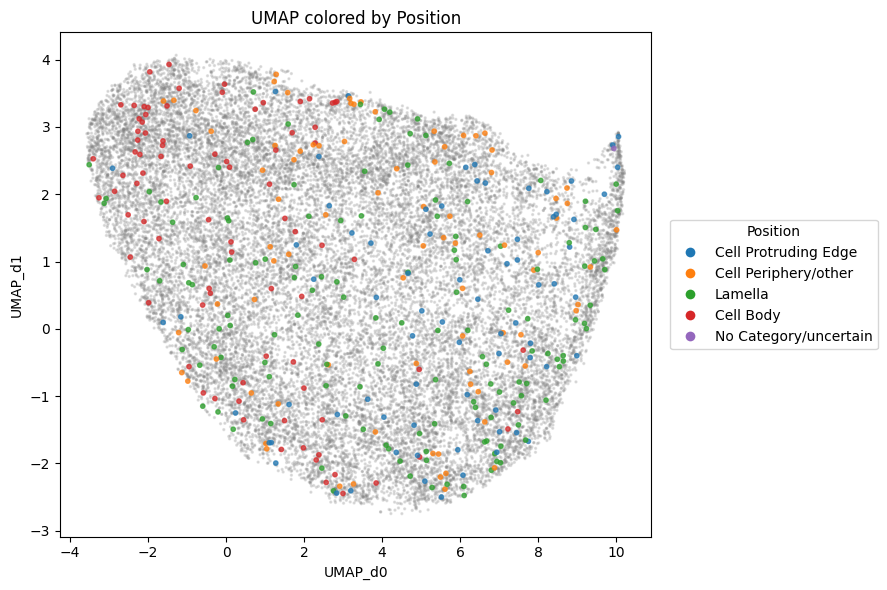

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    lat8_margaret_label_121922["UMAP_d0"],
    lat8_margaret_label_121922["UMAP_d1"],
    c=lat8_margaret_label_121922["Position"].map(position_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=position_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in position_label_order
]
plt.legend(
    handles=handles,
    title="Position",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()


In [11]:
df_clean = lat8_margaret_label_121922[lat8_margaret_label_121922["Position"] != "No Category/uncertain"].copy()


In [12]:
df_clean.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

In [13]:
lat_cols = [f"lat_d{i}" for i in range(8)]

X = df_clean[lat_cols].values
y_FA_class = df_clean["classification"].values
y_position = df_clean["Position"].values

y_FA_class_enc = df_clean["FA_type_id"].values
y_position_enc = df_clean["position_id"].values



joblib.dump(y_position_enc, os.path.join(root_dir, "y_position_enc.pkl"))




['/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323/y_position_enc.pkl']

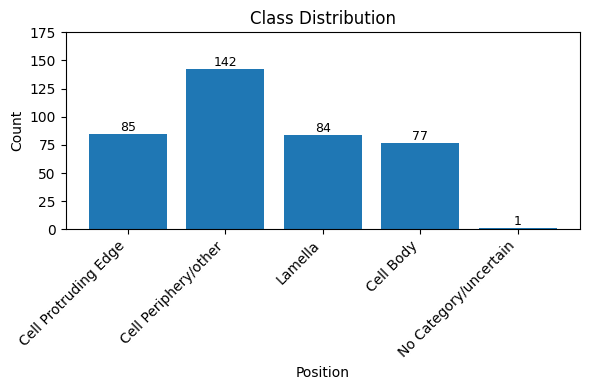

In [14]:
import matplotlib.pyplot as plt
import numpy as np

class_names = position_label_order
n_classes = len(class_names)

# y_enc = lat8_margaret_label_121922["position_id"].dropna().astype(int).values
y_enc = lat8_margaret_label_121922["Position"]


plt.figure(figsize=(6, 4))

counts, bins, patches = plt.hist(
    y_enc,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

# Add count labels on top of each bar
for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(
            x, y,
            int(count),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.ylim([0,175])
plt.tight_layout()
plt.show()



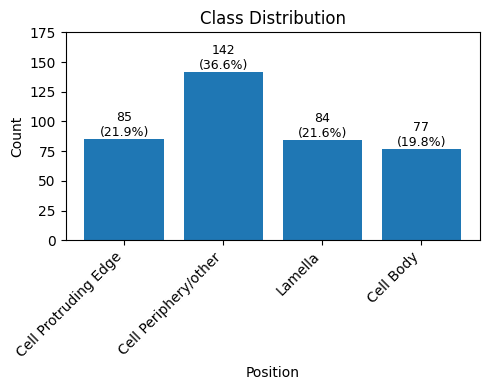

In [15]:
import matplotlib.pyplot as plt
import numpy as np

class_names = position_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(5, 4))

counts, bins, patches = plt.hist(
    y_position,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.ylim([0,175])
plt.tight_layout()
plt.show()


In [16]:

ct = pd.crosstab(
    lat8_margaret_label_121922["Position"],
    lat8_margaret_label_121922["classification"]
)


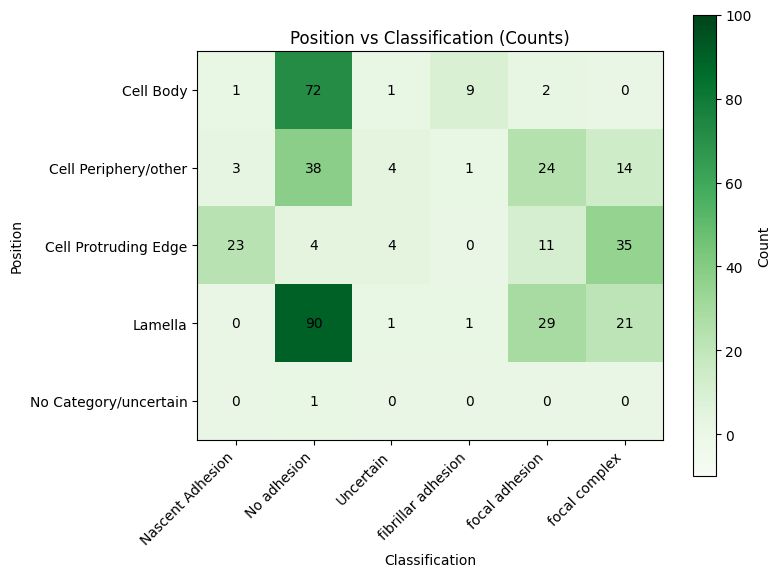

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(ct.values,cmap='Greens', vmin=-10,vmax=100)

ax.set_xticks(np.arange(ct.shape[1]))
ax.set_yticks(np.arange(ct.shape[0]))

ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticklabels(ct.index)

ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position vs Classification (Counts)")

# annotate cells
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j],
                ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()


In [18]:
indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_FA_class_enc,   # primary task
    random_state=42
)

X_train = X[train_idx]
X_val   = X[val_idx]

y_FA_class_train = y_FA_class_enc[train_idx]
y_FA_class_val   = y_FA_class_enc[val_idx]

y_position_train = y_position_enc[train_idx]
y_position_val   = y_position_enc[val_idx]


In [19]:
pipe_position = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])


In [20]:
pipe_position.fit(X_train, y_position_train)


/home/ldin/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [22]:
y_position_val_pred = pipe_position.predict(X_val)

print("Validation classification report:")
print(classification_report(
    y_position_val,
    y_position_val_pred,
    target_names=position_label_order[:-1]
))


Validation classification report:
                      precision    recall  f1-score   support

Cell Protruding Edge       0.21      0.31      0.25        13
Cell Periphery/other       0.13      0.13      0.13        15
             Lamella       0.38      0.21      0.27        29
           Cell Body       0.46      0.62      0.53        21

            accuracy                           0.32        78
           macro avg       0.30      0.32      0.30        78
        weighted avg       0.33      0.32      0.31        78



In [23]:
cm = confusion_matrix(y_position_val, y_position_val_pred)

cm_df = pd.DataFrame(
    cm,
    index=position_label_order[:-1],
    columns=position_label_order[:-1]
)

cm_df


,Cell Protruding Edge,Cell Periphery/other,Lamella,Cell Body
Cell Protruding Edge,4,3,4,2
Cell Periphery/other,8,2,2,3
Lamella,6,7,6,10
Cell Body,1,3,4,13


In [24]:
coef = pd.DataFrame(
    pipe_position.named_steps["clf"].coef_,
    columns=lat_cols,
    index=position_label_order[:-1]
)

coef


,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
Cell Protruding Edge,-0.064255,-0.131642,-0.076919,0.110993,-0.074634,0.247283,-0.268700,-0.471187
Cell Periphery/other,0.191884,0.367236,0.079853,0.165584,-0.020385,0.514093,0.027103,-0.031546
Lamella,-0.094933,-0.038921,-0.111923,0.156343,-0.115236,-0.112235,-0.476739,0.160202
Cell Body,-0.032696,-0.196674,0.108989,-0.432919,0.210255,-0.649142,0.718337,0.342530


In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_position_val, y_position_val_pred)
class_names = position_label_order[:-1]


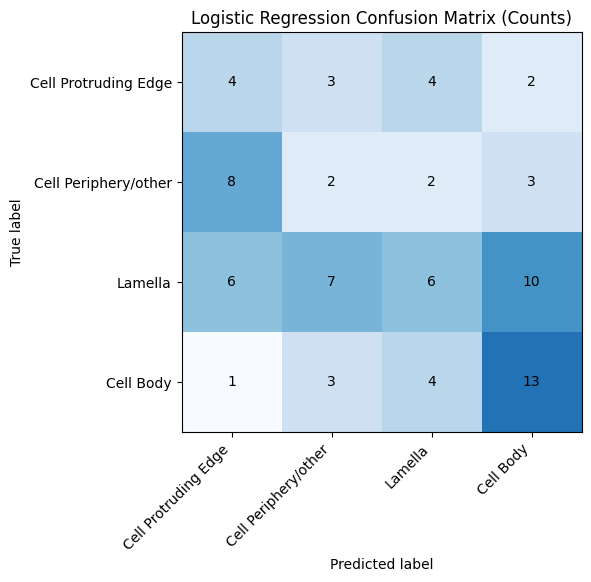

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),  cmap="Blues",vmax=4.5)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Logistic Regression Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


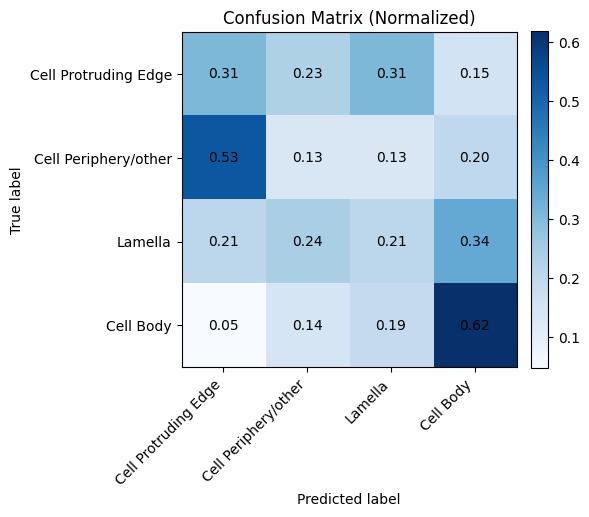

In [27]:
from matplotlib.colors import PowerNorm

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 6))


im = ax.imshow(
    cm_norm,
    cmap="Blues"
)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Normalized)")

# annotate cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


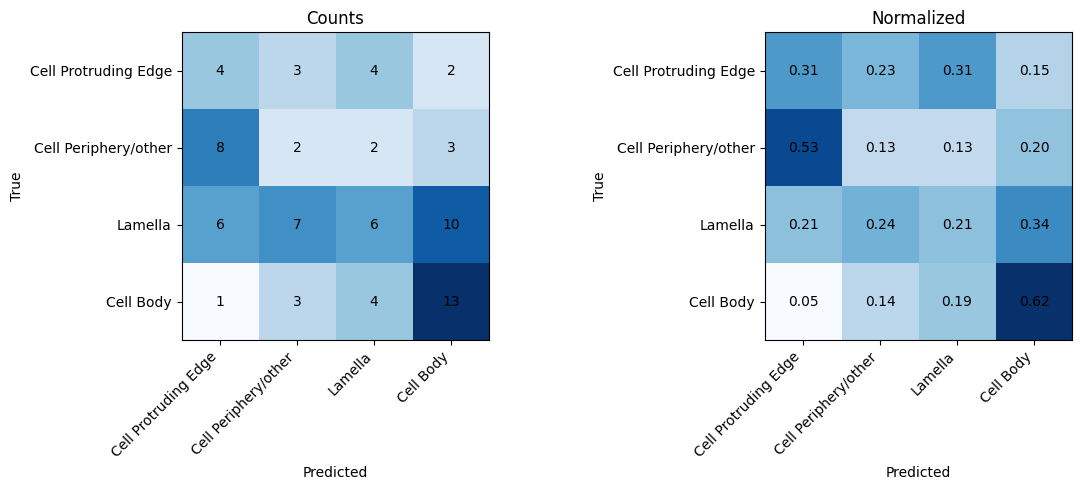

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(
    axes,
    [cm, cm_norm],
    ["Counts", "Normalized"]
):
    im = ax.imshow(np.sqrt(mat),   cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt = mat[i, j] if title == "Counts" else f"{mat[i, j]:.2f}"
            ax.text(j, i, txt, ha="center", va="center")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [29]:
y_position_train_pred = pipe_position.predict(X_train)
print("Train accuracy:", (y_position_train_pred == y_position_train).mean())


Train accuracy: 0.43870967741935485


# Logistic regression cannot separate samples
Try other higher level ones

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_position = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_position.fit(X_train, y_position_train)

y_position_val_pred = rf_position.predict(X_val)
print(classification_report(y_position_val, y_position_val_pred, target_names=position_label_order[:-1]))


                      precision    recall  f1-score   support

Cell Protruding Edge       0.17      0.15      0.16        13
Cell Periphery/other       0.31      0.33      0.32        15
             Lamella       0.45      0.45      0.45        29
           Cell Body       0.62      0.62      0.62        21

            accuracy                           0.42        78
           macro avg       0.39      0.39      0.39        78
        weighted avg       0.42      0.42      0.42        78



In [31]:
cm = confusion_matrix(y_position_val, y_position_val_pred)
class_names = position_label_order[:-1]


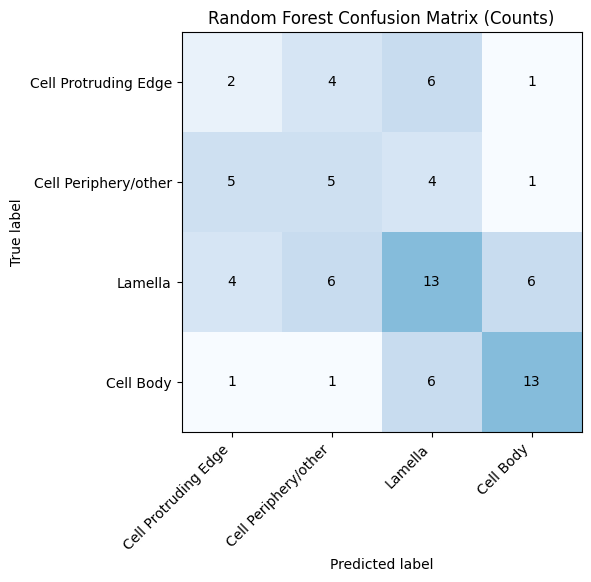

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),    cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb_position = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_position.fit(X_train, y_position_train)

y_position_train_pred = gb_position.predict(X_train)

y_position_val_pred = gb_position.predict(X_val)
print(classification_report(y_position_val, y_position_val_pred, target_names=position_label_order[:-1]))


                      precision    recall  f1-score   support

Cell Protruding Edge       0.18      0.15      0.17        13
Cell Periphery/other       0.07      0.07      0.07        15
             Lamella       0.49      0.59      0.53        29
           Cell Body       0.65      0.52      0.58        21

            accuracy                           0.40        78
           macro avg       0.35      0.33      0.34        78
        weighted avg       0.40      0.40      0.39        78



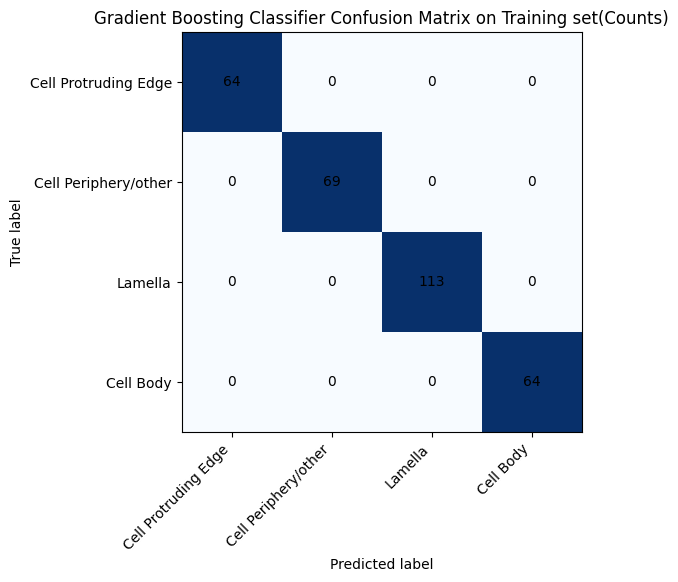

In [34]:
cm = confusion_matrix(y_position_train, y_position_train_pred)
class_names = position_label_order[:-1]
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix on Training set(Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [35]:
A = y_position_val==y_position_val_pred
A.sum()

31

In [36]:
A = y_position_val!=y_position_val_pred
A.sum()

47

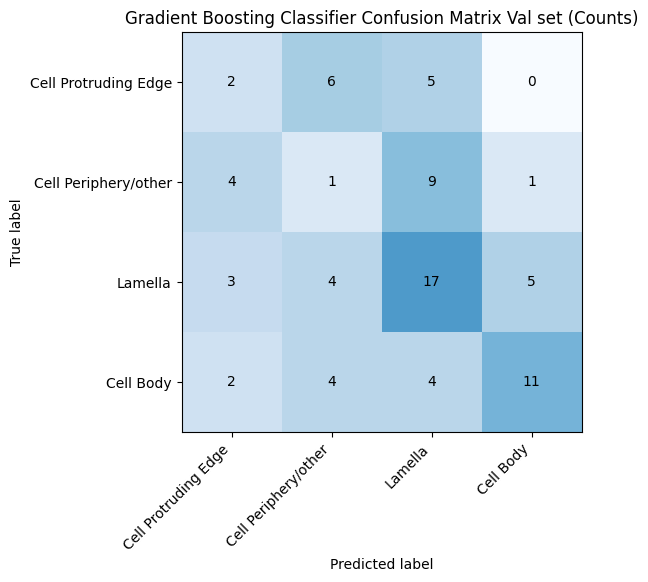

In [37]:

cm = confusion_matrix(y_position_val, y_position_val_pred)
class_names = position_label_order[:-1]
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix Val set (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [38]:
joblib.dump(gb_position, "../../results/pax_AE_lat8_position_gb_classifier.joblib")

['../../results/pax_AE_lat8_position_gb_classifier.joblib']

In [59]:
lat_cols = [f"lat_d{i}" for i in range(8)]

X_all = patch_label_df[lat_cols].values
umap_all_d0 = patch_label_df['UMAP_d0']
umap_all_d1 = patch_label_df['UMAP_d1']
front_flag_all = patch_label_df['front_flag']

y_position_all_pred = gb_position.predict(X_all)

In [60]:
front_flag_all = patch_label_df['front_flag']

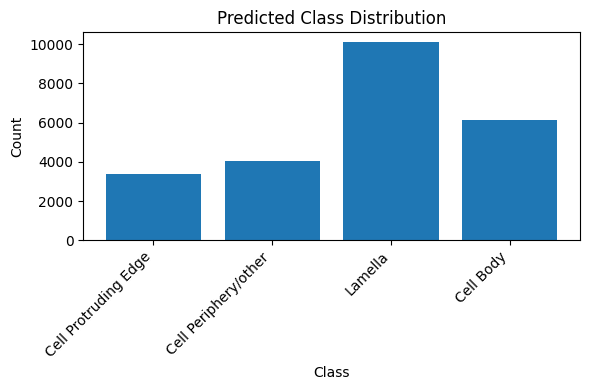

In [61]:

class_names = position_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    y_position_all_pred,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()


In [64]:
# id -> color (via label)
fa_id_to_color = {
    i: position_label_to_color[label]
    for i, label in enumerate(position_label_order)
}

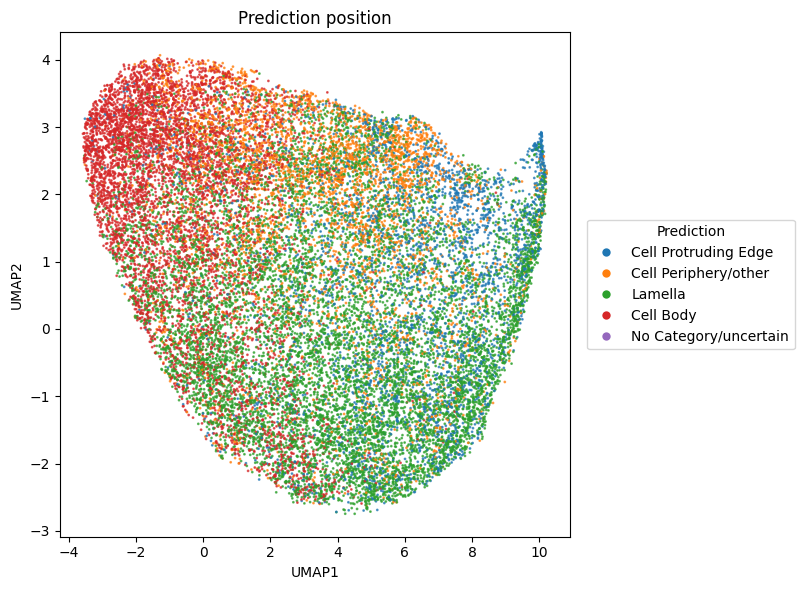

In [65]:
# plot the predictions with Gradient Boosting Classifier
mask = y_position_all_pred > -1

pred_ids = y_position_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction position")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=position_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in position_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [69]:
df_clean.columns


Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'FA_type_id', 'position_id'],
      dtype='object')

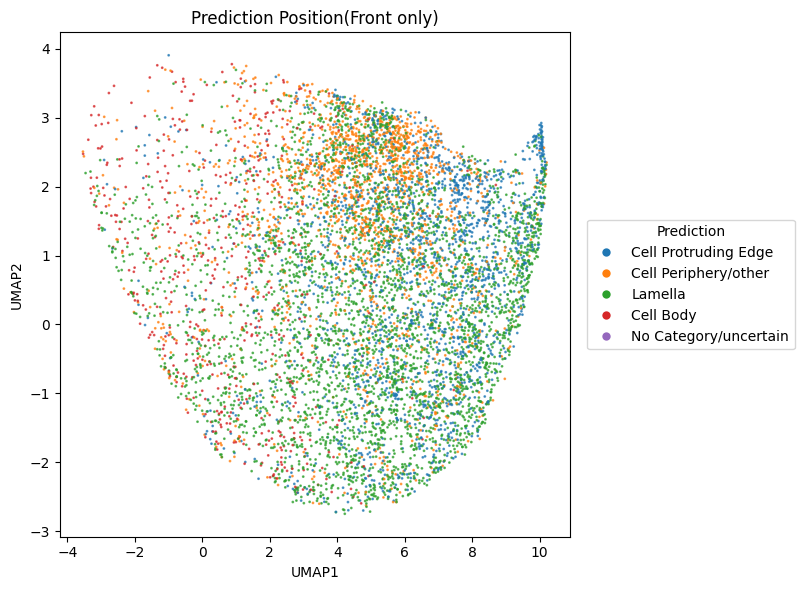

In [67]:

mask = front_flag_all > 0

pred_ids = y_position_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction Position(Front only)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=position_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in position_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



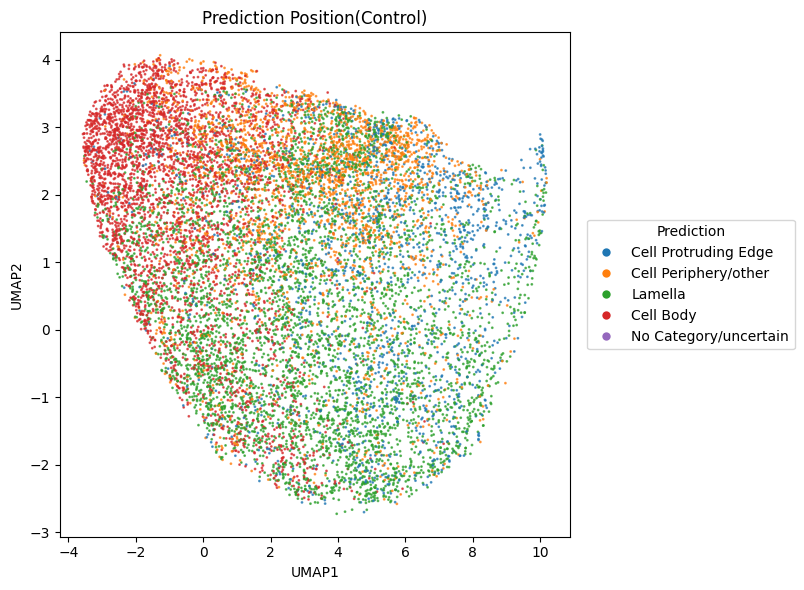

In [79]:
mask = patch_label_df['group'].values == 'control'

pred_ids = y_position_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction Position(Control)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=position_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in position_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [83]:
joblib.dump(y_position_all_pred, os.path.join(root_dir, "y_position_all_pred.pkl"))

['/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323/y_position_all_pred.pkl']

In [84]:
joblib.dump(y_position_enc, os.path.join(root_dir, "y_position_enc.pkl"))



['/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323/y_position_enc.pkl']

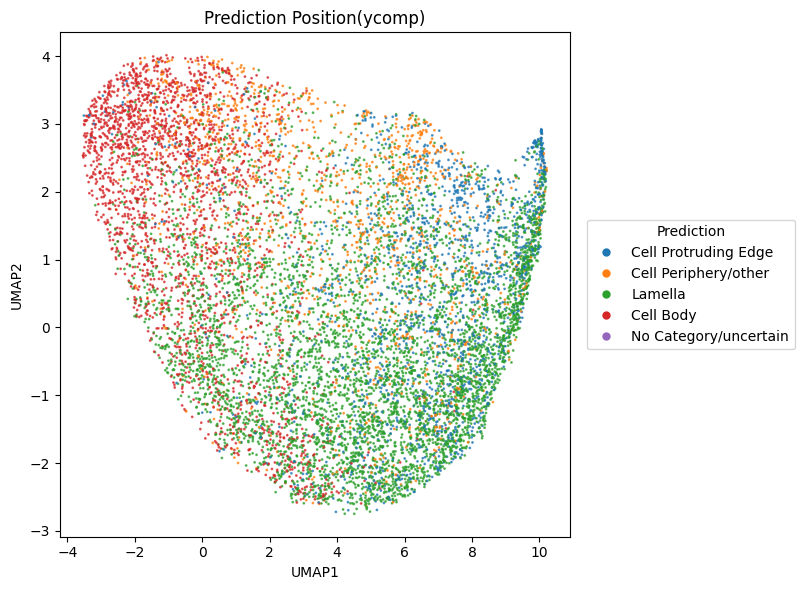

In [80]:
mask = patch_label_df['group'].values == 'ycomp'

pred_ids = y_position_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction Position(ycomp)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=position_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in position_label_order
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [78]:
patch_label_df['group']


0        control
1        control
2        control
3        control
4        control
          ...   
23651      ycomp
23652      ycomp
23653      ycomp
23654      ycomp
23655      ycomp
Name: group, Length: 23656, dtype: object

In [75]:
y_position_all_pred.shape

(23656,)